In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('data/etsy_clean.csv')
df = df.dropna(subset=['sale_price'])

print(f"Total rows: {len(df)}")
print(f"Price range: ₹{df['sale_price'].min()} — ₹{df['sale_price'].max()}")

Total rows: 125
Price range: ₹1685.0 — ₹249965.0


Category distribution:
category
Mid-range    54
Budget       53
Premium      13
Luxury        5
Name: count, dtype: int64


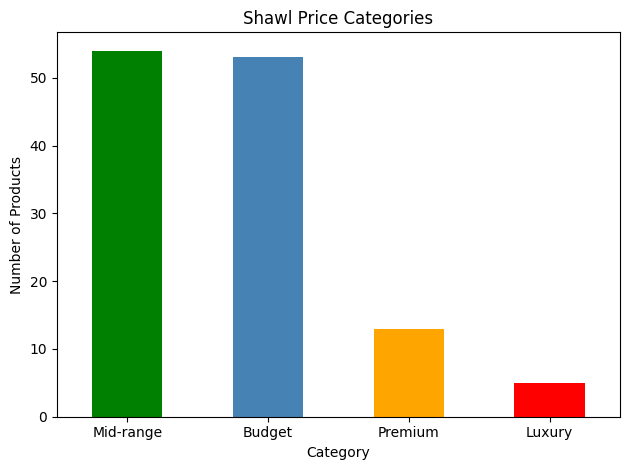

In [2]:
def categorize_price(price):
    if price < 8000:
        return 'Budget'
    elif price < 25000:
        return 'Mid-range'
    elif price < 80000:
        return 'Premium'
    else:
        return 'Luxury'

df['category'] = df['sale_price'].apply(categorize_price)

print("Category distribution:")
print(df['category'].value_counts())

# visualize
df['category'].value_counts().plot(kind='bar', color=['green', 'steelblue', 'orange', 'red'])
plt.title('Shawl Price Categories')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [3]:
from sklearn.preprocessing import LabelEncoder

# add features
df['title_length'] = df['title'].str.len()
df['has_embroidered'] = df['title'].str.lower().str.contains('embroidered').astype(int)
df['has_kani'] = df['title'].str.lower().str.contains('kani').astype(int)
df['has_luxury'] = df['title'].str.lower().str.contains('luxury').astype(int)
df['has_handmade'] = df['title'].str.lower().str.contains('handmade').astype(int)
df['has_authentic'] = df['title'].str.lower().str.contains('authentic').astype(int)
df['discount_pct'] = df['discount'].str.replace('(','').str.replace('% off)','').str.strip()
df['discount_pct'] = pd.to_numeric(df['discount_pct'], errors='coerce').fillna(0)

features = ['title_length', 'has_embroidered', 'has_kani', 'has_luxury',
            'has_handmade', 'has_authentic', 'discount_pct']

X = df[features]
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Budget       1.00      1.00      1.00        10
      Luxury       0.00      0.00      0.00         1
   Mid-range       0.91      0.83      0.87        12
     Premium       0.50      1.00      0.67         2

    accuracy                           0.88        25
   macro avg       0.60      0.71      0.63        25
weighted avg       0.88      0.88      0.87        25



/home/syedtaha/shawl-business-intelligence/shawl-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/syedtaha/shawl-business-intelligence/shawl-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/syedtaha/shawl-business-intelligence/shawl-env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [4]:
def classify_shawl(title, discount_pct):
    features_input = pd.DataFrame([[
        len(title),
        1 if 'embroidered' in title.lower() else 0,
        1 if 'kani' in title.lower() else 0,
        1 if 'luxury' in title.lower() else 0,
        1 if 'handmade' in title.lower() else 0,
        1 if 'authentic' in title.lower() else 0,
        discount_pct
    ]], columns=features)

    prediction = model.predict(features_input)[0]
    probability = model.predict_proba(features_input).max() * 100

    print(f"Title: {title}")
    print(f"Category: {prediction}")
    print(f"Confidence: {probability:.1f}%")
    print()

# test
classify_shawl("Authentic Hand Embroidered Kani Pashmina Luxury Kashmiri Wrap", 20)
classify_shawl("Soft Pashmina Shawl Wrap", 50)
classify_shawl("Pure Handmade Sozni Embroidered Premium Kashmiri Shawl", 25)

Title: Authentic Hand Embroidered Kani Pashmina Luxury Kashmiri Wrap
Category: Mid-range
Confidence: 69.0%

Title: Soft Pashmina Shawl Wrap
Category: Budget
Confidence: 94.0%

Title: Pure Handmade Sozni Embroidered Premium Kashmiri Shawl
Category: Mid-range
Confidence: 35.0%

